### PROJECT: LOGISTIC REGRESSION FROM SCRATCH WITH NUMPY

Goal: To implement a logistic regression model from scratch to predict passenger survival on the Titanic.


### 1. Import all necessary libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score

### 2. Data Loading and Preprocessing

2.1 Loading and Cleaning Data

In [25]:
# Load the Titanic dataset
titanic_df = pd.read_csv('Titanic-Dataset.csv')

# Remove columns that aren't useful for prediction
titanic_df = titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)

# Fill in missing 'Age' values with median age
median_age = titanic_df['Age'].median()
titanic_df["Age"] = titanic_df["Age"].fillna(median_age)

# Fill in missing 'Embarked' value by filling with the most common part
mode_embarked = titanic_df['Embarked'].mode()[0]
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(mode_embarked)

# Convert categorical 'Sex' column to numeric (0 for male, 1 for female)
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

# Convert categorical 'Embarked' column to numeric using one-hot encoding
embarked_dummies = pd.get_dummies(titanic_df['Embarked'], prefix='Embarked')
titanic_df = pd.concat([titanic_df, embarked_dummies], axis=1)
titanic_df = titanic_df.drop('Embarked', axis=1)

2.2 Feature-Target and Train-Test Split

In [26]:
# Feature-Target Split
X = titanic_df.drop('Survived', axis=1) # Model is predicting probability that a passenger survived, so we can't use this
y = titanic_df['Survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. Logistic Regression Model Implementation
This class implements logistic regression from scratch. The hypothesis is passed through a Sigmoid function to output a probability:
$$ h_{\theta}(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}} $$
The model is optimized using Gradient Descent to minimize the Log-Loss cost function, $J(\theta)$:
$$ J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_{\theta}(x^{(i)})) + (1-y^{(i)}) \log(1 - h_{\theta}(x^{(i)}))] $$

In [27]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class LogisticRegression:
    """
    Assumes the bias term (column of ones) is pre-pended to the feature matrix X.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        """Trains the logistic regression model using gradient descent."""
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)

        # Gradient Descent loop
        for _ in range(self.n_iterations):
            # Calculate the linear part and apply the sigmoid function
            z = X @ self.theta
            predictions = sigmoid(z)

            # Calculate Log-Loss cost and store it
            cost = (-1 / n_samples) * (np.dot(y, np.log(predictions)) + np.dot((1 - y), np.log(1 - predictions)))
            self.cost_history.append(cost)

            # The gradient and update rule are the same as linear regression
            gradient = (1 / n_samples) * (X.T @ (predictions - y))
            self.theta -= self.learning_rate * gradient

    def predict(self, X):
        """Makes binary predictions (0 or 1) using the learned theta."""
        probabilities = sigmoid(X @ self.theta)
        # Convert probabilities to class labels using a 0.5 threshold
        return [1 if i > 0.5 else 0 for i in probabilities]

### 4. Preparing Data and Model Training

In [28]:
# Feature Scaling: Initialize and apply the StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add a column of ones for the bias term (theta_0)
X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

# Initialize and train the model
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_b, y_train)

### 5. Results and Evaluation
5.1 Visuialising the Cost Function

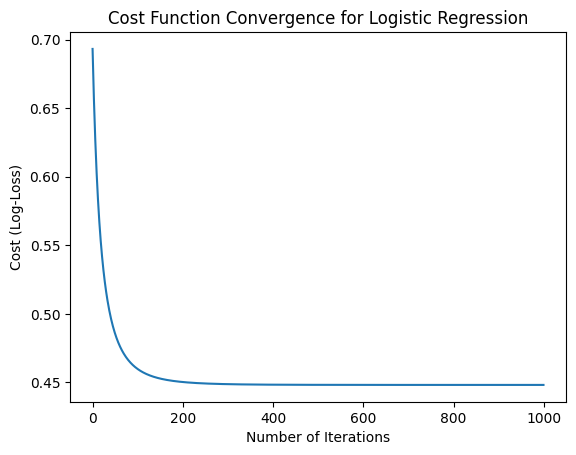

In [29]:
# Plot the cost history
plt.plot(model.cost_history)
plt.title("Cost Function Convergence for Logistic Regression")
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (Log-Loss)")
plt.show()

5.2 Model Validation against Scikit-learn

In [30]:
# Make predictions on the test set
predictions = model.predict(X_test_b)

# Calculate accuracy
your_accuracy = accuracy_score(y_test, predictions)
print(f"Your From-Scratch Model's Accuracy: {your_accuracy:.4f}")

# Initialize and train Scikit-learn's model
sklearn_model = SklearnLogisticRegression()
sklearn_model.fit(X_train_scaled, y_train)

# Make predictions and calculate accuracy
sklearn_predictions = sklearn_model.predict(X_test_scaled)
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f"Scikit-learn's Model Accuracy:      {sklearn_accuracy:.4f}")

Your From-Scratch Model's Accuracy: 0.8101
Scikit-learn's Model Accuracy:      0.8101


### 6. Conclusion
The from-scratch logistic regression model performed successfully, achieving an accuracy of 81.01%, which is identical to the Scikit-learn library's result of 81.01%. This validates the correctness of the custom implementation.